In [4]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
#from PIL import Image, ImageDraw, ImageFilter
#from astropy.utils.data import download_file
from photutils.isophote import Ellipse
from matplotlib import colors

# subcomponent

In [5]:
f_dir = 'GALFIT_model/'
##################################

N_rp = 0.000000001
model =  f_dir + 'subcomps.fits'
hdu_SbC = fits.open(model)
# 1 data, 2 disk, 3 inner disk, 4 bar, 5 point sourse

sky = hdu_SbC[6].data

disk = hdu_SbC[2].data 

# Remove the negative, nan, and inf values from the images
in_disk = hdu_SbC[3].data
in_disk[in_disk==0] = N_rp
in_disk[in_disk<0.0] = N_rp
np.nan_to_num(in_disk, copy=False, nan=N_rp, posinf=N_rp, neginf=N_rp) # replace nan value with 1

bar = hdu_SbC[4].data 
bar[bar==0] = N_rp
bar[bar<0.0] = N_rp
np.nan_to_num(bar, copy=False, nan=N_rp, posinf=N_rp, neginf=N_rp) 

center = hdu_SbC[5].data
center[center==0] = N_rp
center[center<0.0] = N_rp
np.nan_to_num(center, copy=False, nan=N_rp, posinf=N_rp, neginf=N_rp) 

center = hdu_SbC[5].data
center[center==0] = N_rp
center[center<0.0] = N_rp
np.nan_to_num(center, copy=False, nan=N_rp, posinf=N_rp, neginf=N_rp)

######################################3

model =  f_dir + 'imgblock.fits'
hdu_mo = fits.open(model)
data_org = hdu_mo[1].data # 1 data, 2 model, 3 residual
data_model = hdu_mo[2].data 
data_model_res = hdu_mo[3].data   

model =  f_dir + 'NGC4371_S4G_cut_EL_Fil.fits'
data_org_F = fits.open(model)
data_org_F = data_org_F[0].data 

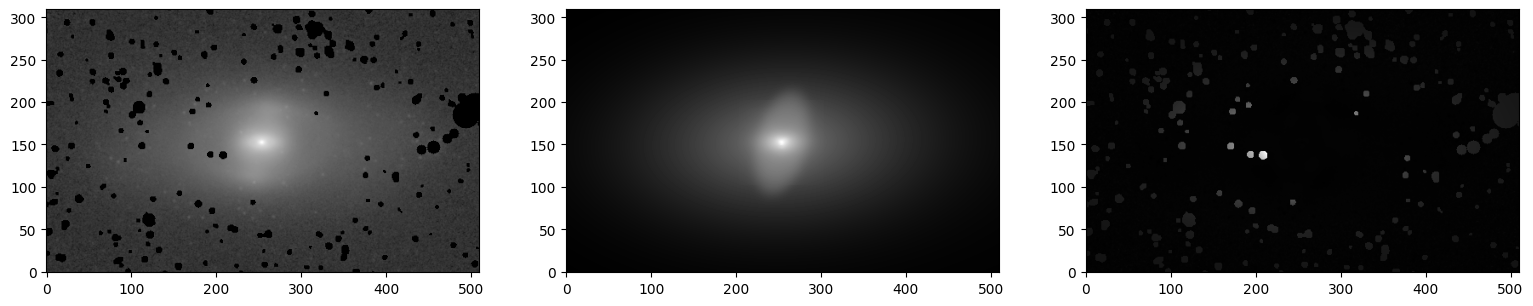

In [6]:
co = 'gray'

plt.figure(figsize=(19, 7))
plt.figure(1)

plt.subplot(131)
plt.imshow(data_org_F,cmap=co, origin='lower',norm=colors.LogNorm() )
#plt.imshow(data_org,cmap=co, origin='image',norm=colors.LogNorm(), vmin=mi1, vmax=ma1)

plt.subplot(132)
plt.imshow(data_model,cmap=co, origin='lower',norm=colors.LogNorm())

plt.subplot(133)
pb=plt.imshow((data_model-data_org_F)/data_org_F,cmap=co, origin='lower')
#cc=plt.colorbar(pb,shrink=0.4)

In [11]:
# Apply ellipse analysis to the S4G image

nclip=2
sclip=3
sma0 = 20
ellipse1 = Ellipse(data_org)
iso_img = ellipse1.fit_image(sma0=sma0,sclip=sclip, nclip=nclip)

ellipse1_F = Ellipse(data_org_F)
iso_img_F = ellipse1_F.fit_image(sma0=sma0,sclip=sclip, nclip=nclip)

In [12]:
# Model 

nclip=2
sclip=3
sma0 = 20
ellipse2 = Ellipse(data_model)
iso_model = ellipse2.fit_image(sclip=sclip, nclip=nclip)

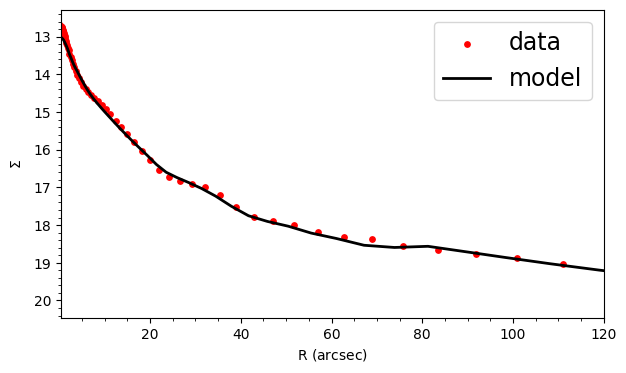

In [15]:
# Comparing the surface density (unit is not physical here) 

arc_pix = 0.75
Z0=21

fig, ax = plt.subplots(figsize=(7, 4))

ax.scatter(iso_img_F.sma*arc_pix, -2.5*np.log10(iso_img_F.intens)+2.5*np.log10(arc_pix)+Z0, color='red',s=15, label = 'data')
ax.plot(iso_model.sma*arc_pix, -2.5*np.log10(iso_model.intens)+2.5*np.log10(arc_pix)+Z0, color='black', label = 'model', lw=2.0)

ax.set_xlabel('$\mathrm{R}$ (arcsec)')
ax.set_ylabel('$ \Sigma$',labelpad=7)

ax.legend(fontsize=17)
#ax.legend()
ax.set_xlim(0.4,120)
#ax.set_ylim(15.5,24)
plt.minorticks_on()
plt.gca().invert_yaxis()

# Isophotes, Elliptisity

<Figure size 1000x500 with 0 Axes>

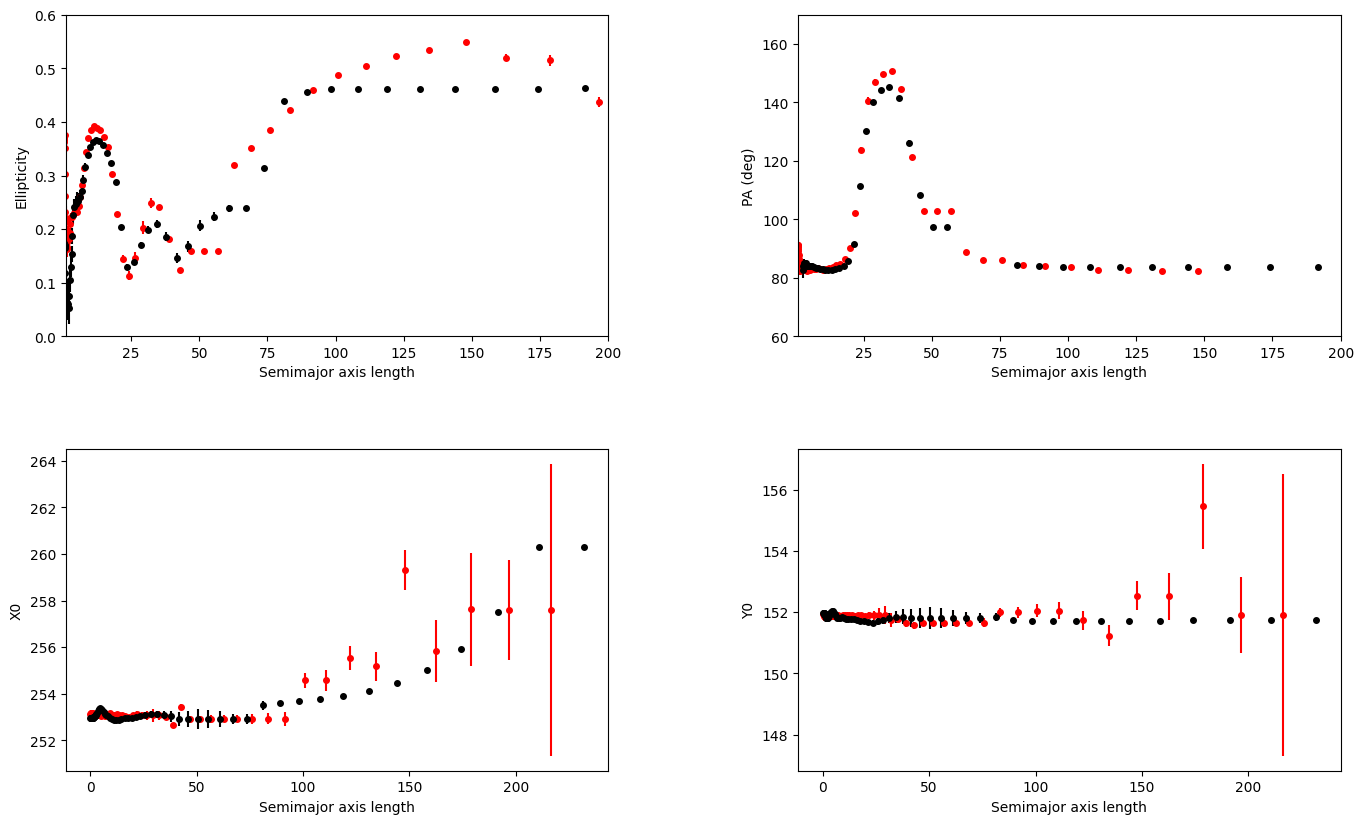

In [10]:
plt.figure(figsize=(15, 9))
plt.figure(1)

plt.subplot(221)
plt.errorbar(iso_img.sma*arc_pix, iso_img.eps, yerr=iso_img.ellip_err, color='red', fmt='o', markersize=4)
plt.xlim(1,200)
plt.ylim(0,0.6)
plt.xlabel('Semimajor axis length')
plt.ylabel('Ellipticity')

plt.subplot(222)
plt.errorbar(iso_img.sma*arc_pix, (iso_img.pa/np.pi*180.)+82, yerr=iso_img.pa_err/np.pi* 80., color='red', fmt='o', markersize=4)
plt.xlim(1,200)
plt.ylim(60,170)
plt.xlabel('Semimajor axis length')
plt.ylabel('PA (deg)')

plt.subplot(223)
plt.errorbar(iso_img.sma*arc_pix, iso_img.x0, yerr=iso_img.x0_err, color='red', fmt='o', markersize=4)
plt.xlabel('Semimajor axis length')
plt.ylabel('X0')

plt.subplot(224)
plt.errorbar(iso_img.sma*arc_pix, iso_img.y0, yerr=iso_img.y0_err, color='red', fmt='o', markersize=4)
plt.xlabel('Semimajor axis length')
plt.ylabel('Y0')


plt.subplots_adjust(top=0.92, bottom=0.08, left=0.10, right=0.95, hspace=0.35, wspace=0.35)
plt.figure(figsize=(10, 5))
plt.figure(1)

plt.subplot(221)
plt.errorbar(iso_model.sma*arc_pix, iso_model.eps, yerr=iso_model.ellip_err, color='black', fmt='o', markersize=4)
plt.xlabel('Semimajor axis length')
plt.ylabel('Ellipticity')

plt.subplot(222)
plt.errorbar(iso_model.sma*arc_pix, (iso_model.pa/np.pi*180.)+82, yerr=iso_model.pa_err/np.pi* 80., color='black', fmt='o', markersize=4)
plt.xlabel('Semimajor axis length')
plt.ylabel('PA (deg)')

plt.subplot(223)
plt.errorbar(iso_model.sma*arc_pix, iso_model.x0, yerr=iso_model.x0_err, color='black', fmt='o', markersize=4)
plt.xlabel('Semimajor axis length')
plt.ylabel('X0')

plt.subplot(224)
plt.errorbar(iso_model.sma*arc_pix, iso_model.y0, yerr=iso_model.y0_err, color='black', fmt='o', markersize=4)
plt.xlabel('Semimajor axis length')
plt.ylabel('Y0')

plt.subplots_adjust(top=0.92, bottom=0.08, left=0.10, right=0.95, hspace=0.35, wspace=0.35)
